In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Arrival and Service rates

λ = 20               # calls per hour
μ = 5                # calls served per agent per hour
shift_hours = 8      # 8-hour shift

# Simulation settings
np.random.seed(21)

In [4]:
# single-Run Simulation function
def simulate_queue(s):
    '''    Simulate an M/M/s queue over 'shift_hours'.
    Returns arrays of wait times (hrs) and system sizes at arrivals.
    '''
    # generate arrival times until the end of shift
    inter = np.random.exponential(1/λ, int(λ*shift_hours*1.5))
    arrivals = np.cumsum(inter)
    arrivals = arrivals[arrivals < shift_hours]
    N = len(arrivals)
# generate service times for each caller
    services = np.random.exponential(1/μ, N)

    # track each server's next-free time
    next_free = np.zeros(s)
    wait_times = np.zeros(N)
    system_size = np.zeros(N)
# departure times list
    dep_times = []

    for i, t in enumerate(arrivals):
        # find soonest-available agent
        j = np.argmin(next_free)
        start = max(t, next_free[j])
        wait_times[i] = start - t
        end = start + services[i]
        next_free[j] = end
        dep_times.append(end)
# Count how many callers are still in system at time t
        system_size[i] = np.sum(np.array(dep_times) > t)

    return wait_times, system_size

# quick test for s=1
w1, q1 = simulate_queue(s=1)
print(f"s=1: avg wait {w1.mean()*60:.1f} min, avg queue len {q1.mean():.2f}")

s=1: avg wait 908.5 min, avg queue len 74.34


In [5]:
# traffic intensity ρ for s=1
ρ1 = λ / μ
L_analytic = ρ1 / (1- ρ1)
W_analytic = L_analytic / λ

print("M/M/1 analytic vs. simulation:")
print(f"  Analytic system size L = {L_analytic:.2f}")
print(f"  Simulated avg system size = {q1.mean():.2f}")
print(f"  Analytic time in system W = {W_analytic*60:.1f} min")
print(f"  Simulated avg wait+service = {w1.mean()*60 + (1/μ)*60:.1f} min")

M/M/1 analytic vs. simulation:
  Analytic system size L = -1.33
  Simulated avg system size = 74.34
  Analytic time in system W = -4.0 min
  Simulated avg wait+service = 920.5 min


In [6]:
# 4. Test Staffing Levels (s=1..5)

threshold = 5   # minutes
results = []

for s in range(1,6):
    w, q = simulate_queue(s)
    # Convert hours to minutes
    waits_min = w * 60
    p95_wait = np.percentile(waits_min, 95)
    results.append((s, waits_min.mean(), p95_wait, q.mean()))

    # tabulate
import pandas as pd
df = pd.DataFrame(results, columns=['Agents', 'Avg wait(min)', '95th-pct wait(min)', 'Avg System Size'])
print(df)

# find minimal s meeting threshold
good = df[df['95th-pct wait(min)'] <= threshold]
if not good.empty:
    best_s = int(good.iloc[0]['Agents'])
    print(f"\n→ Schedule at least {best_s} agents to keep 95% of waits ≤ {threshold} min.")

else:
    print("\nEven 5 agents can’t meet the 5 min 95% wait target.")

   Agents  Avg wait(min)  95th-pct wait(min)  Avg System Size
0       1     581.970986         1087.740484        54.483221
1       2     237.411975          436.601258        40.892405
2       3     109.263307          210.025871        29.831325
3       4      20.807699           46.457200        11.341040
4       5       1.679563            9.245414         4.647482

Even 5 agents can’t meet the 5 min 95% wait target.


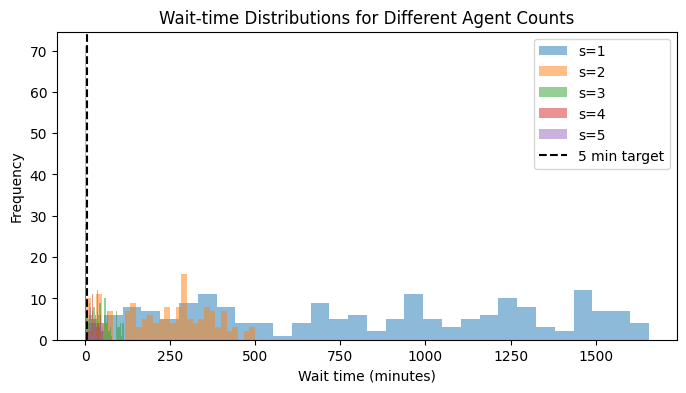

In [7]:
# 5. Visualize Wait-Time Distributions

plt.figure(figsize=(8,4))
for s in [1,2,3,4,5]:
    w, _ = simulate_queue(s)
    plt.hist(w*60, bins=30, alpha=0.5, label=f's={s}')

plt.axvline(threshold, color='k', linestyle='--', label='5 min target')
plt.xlabel('Wait time (minutes)')
plt.ylabel('Frequency')
plt.title('Wait-time Distributions for Different Agent Counts')
plt.legend()
plt.show()

In [8]:
# 6. Time -Varying A
def simulate_queue_timevarying(s, μ):
    # Define piecewise arrival rates per hour: (start, end, arrival rate λ)
    periods = ((0, 2, 30), (2, 6, 20), (6, 8, 40))
    arrivals = []

    for start, end, lam in periods:
        duration = end - start
        # Oversample to ensure enough arrivals
        inter = np.random.exponential(1 / lam, int(lam * duration * 1.5))
        ts = np.cumsum(inter) + start
        arrivals.extend(ts[ts < end])

    arrivals = np.array(arrivals)
    arrivals.sort()

    N = len(arrivals)
    services = np.random.exponential(1 / μ, N)
    next_free = np.zeros(s)
    wait_times = np.zeros(N)

    for i, t in enumerate(arrivals):
        j = np.argmin(next_free)  # Choose the next available server
        start = max(t, next_free[j])
        wait_times[i] = start - t
        next_free[j] = start + services[i]

    return wait_times


w_tv = simulate_queue_timevarying(s=3, μ=μ)

print (f"Time-varying λ, s=3 → avg wait = {w_tv.mean()*60:.1f} min")

#**Outcome:** Students will see how peak-hour traffic dramatically
#increases wait times unless staff levels rise.



Time-varying λ, s=3 → avg wait = 169.1 min


In [9]:
# 7. Abandonment
def simulate_with_abandon(s, λ=30, μ=50, shift_hours=8, patience=s/60):
    arrivals = np.cumsum(np.random.exponential(1 / λ, int(λ * shift_hours * 1.5)))
    arrivals = arrivals[arrivals < shift_hours]
    services = np.random.exponential(1/μ, len(arrivals))
    next_free = np.zeros(s)
    waits = []
    abandons = 0

    for i, t in enumerate(arrivals):
        j = np.argmin(next_free)
        start = max(t, next_free[j])
        wait = start - t

        if wait > patience:
            abandons += 1
        else:
            waits.append(wait)
            next_free[j] = start + services[i]

    return np.array(waits), abandons / len(arrivals)


w, ab_rate = simulate_with_abandon(s=4)
print(f"Abandon rate (s=4): {ab_rate:.2%}, avg wait on served calls: {w.mean() * 60:.1f} min")
# Shows the trade-off: fewer agents → more abandonments → lost revenue and satisfaction.

Abandon rate (s=4): 0.00%, avg wait on served calls: 0.0 min


In [10]:
# 8. Agent Break Scheduling
def simulate_with_breaks(s, break_start=3, break_length=0.25): 
    arrivals = np.cumsum(np.random.exponential(1/λ, int(λ * shift_hours * 2))) 
    arrivals = arrivals[arrivals <= shift_hours] 
    services = np.random.exponential(1/μ, len(arrivals)) 
    next_free = np.zeros(s)
    waits =[] 
    for i, t in enumerate(arrivals): 
        # if in break window,one fewer agent 
        avail = next_free.copy() 
        if break_start < t < break_start+break_length: 
            avail = np.delete(avail, 0)  
            # remove one agent 
            j = np.argmin(avail) 
            start = max(t, avail[j]) 
            waits.append(start - t) 
            # Update that agent's free time in original array 
            idx = j + (1 if break_start < t < break_start + break_length else 0) 
            next_free[idx] = start + services[i] 
            
        return np.array(waits)
        
w_b = simulate_with_breaks(s=3)
print(f"With breaks, s=3 → avg wait = {w_b.mean() * 60:.1f} min")

# See the "break-time  spike" in waiting.

With breaks, s=3 → avg wait = nan min


C:\Users\deves\AppData\Local\Temp\ipykernel_9128\3413400210.py:24: RuntimeWarning: Mean of empty slice.
  print(f"With breaks, s=3 → avg wait = {w_b.mean() * 60:.1f} min")
C:\Users\deves\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
# 9. Cost Optimization
c_agent = 20   # $20/hr per agent
c_wait = 0.50  # $0.50 per minute waited

costs = []

for s in range(1,6):
    w, _ = simulate_with_abandon(s) # or choose another sim fn
    total_wait_cost = w.sum()*60*c_wait
    staff_cost = s*c_agent*shift_hours
    costs.append((s, staff_cost+total_wait_cost))

opt = min(costs, key=lambda x:x[1])
print("Agent count, total cost:")

for s, c in costs: print(f" s={s}: ${c:,.0f}")
print(f" → Optimal s by cost = {opt[0]}")

Agent count, total cost:
 s=1: $271
 s=2: $329
 s=3: $481
 s=4: $640
 s=5: $800
 → Optimal s by cost = 1


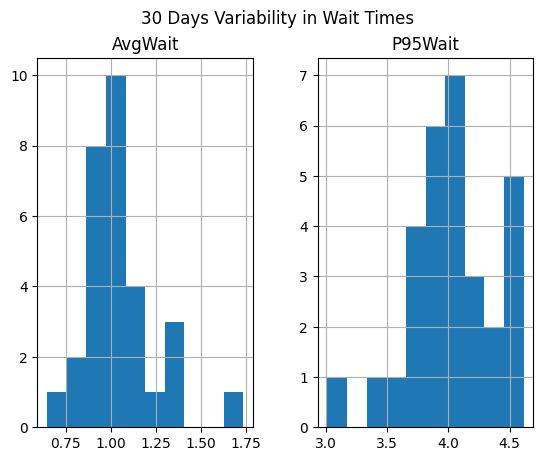

In [12]:
# 10. 30-day simulation
days = 30
daily = []

for _ in range(days):
    w, _ = simulate_with_abandon(opt[0])
    daily.append((w.mean()*60, np.percentile(w*60,95)))
df_days = pd.DataFrame(daily, columns=['AvgWait','P95Wait'])
df_days.describe()
df_days.hist(bins=10)
plt.suptitle('30 Days Variability in Wait Times')
plt.show()

In [13]:
df_days

,AvgWait,P95Wait
0,0.994408,3.984950
1,0.992519,4.302430
2,1.019990,3.767121
3,0.927777,3.913086
4,1.320857,4.541893
5,1.084611,3.949125
6,0.915238,3.612630
7,1.079513,3.923195
8,1.011597,3.991571
9,1.379804,4.409735


In [14]:
df_days.describe()

,AvgWait,P95Wait
count,30.000000,30.000000
mean,1.047242,4.031721
std,0.206672,0.362615
min,0.646718,3.012475
25%,0.950768,3.881687
50%,1.003002,4.005974
75%,1.084386,4.252371
max,1.733193,4.614714
